In [3]:
import numpy as np
import matplotlib.pyplot as plt
from blackscholes import call_price, delta, simulate_path

# Parameters
S0 = 100      # initial stock price
K = 100       # strike price
T = 1         # 1 year
r = 0.05      # risk-free rate
sigma = 0.2   # volatility
steps = 252   # daily steps

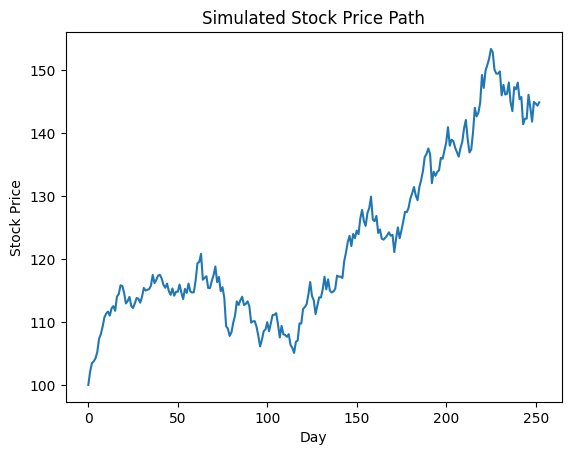

In [4]:
dt = T / steps
S_path = [S0]

for i in range(steps):
    z = np.random.normal()
    S_next = S_path[-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    S_path.append(S_next)

S_path = np.array(S_path)
plt.plot(S_path)
plt.title('Simulated Stock Price Path')
plt.xlabel('Day')
plt.ylabel('Stock Price')
plt.show()

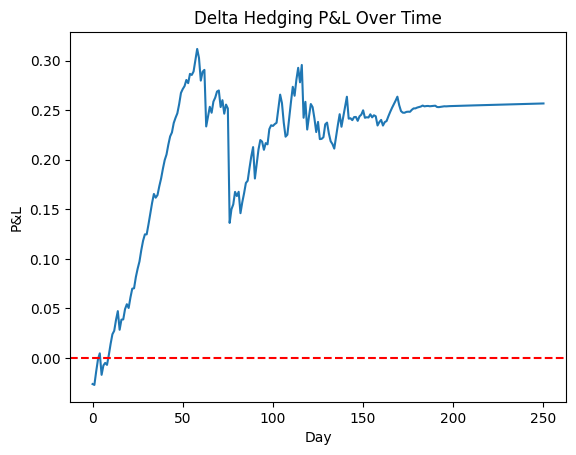

In [5]:
# Sell the call option - collect premium
option_premium = call_price(S0, K, T, r, sigma)

# Initial delta hedge
delta_held = delta(S0, K, T, r, sigma, option_type='call')
cash = option_premium - delta_held * S0  # cash from premium minus cost of shares bought

pnl = []

for i in range(1, steps):
    tau = T - i * dt  # time remaining
    S_curr = S_path[i]
    S_prev = S_path[i-1]
    
    # New delta
    new_delta = delta(S_curr, K, max(tau, 1e-8), r, sigma, option_type='call')
    
    # Rebalance — buy/sell shares to match new delta
    cash -= (new_delta - delta_held) * S_curr
    cash *= np.exp(r * dt)  # cash earns risk-free rate
    delta_held = new_delta
    
    # Portfolio value = cash + stock position - option liability
    option_value = call_price(S_curr, K, max(tau, 1e-8), r, sigma)
    portfolio = cash + delta_held * S_curr - option_value
    pnl.append(portfolio)

plt.plot(pnl)
plt.title('Delta Hedging P&L Over Time')
plt.xlabel('Day')
plt.ylabel('P&L')
plt.axhline(y=0, color='r', linestyle='--')
plt.savefig('delta_hedging.png', dpi=150, bbox_inches='tight')
plt.show()